# v30_tcn — TCN v22 (dilated + SE, BẢN TCN TỐT NHẤT) trên PIPELINE v30

**Giữ nguyên kiến trúc v22** (2 stack × dilated Conv1D d=1,2,4,8 k7 + SE + residual causal, head GAP+GMP) — bản có **Trans F1 0.855 cao nhất mọi model**. Chạy trên **pipeline v30**:
- gyro **dps clip±500/500** (gyro sống INT8), **Trans theo sự kiện gyro RMS>20**, augment ×0.9/1.1, w0.55.
- Reuse **`cache_v30`** → không windowing lại.

⚠️ Dilation + SE là nguồn sức mạnh Trans (v22_optimize bỏ chúng → Trans sụp 0.667). Giữ nguyên. Dilation KHÔNG được ESP-NN tăng tốc (chậm hơn trên chip) — đánh đổi chấp nhận được vì PSRAM mới là nghẽn.

## 📌 Ghi chú
- Kiến trúc = **TCN v22** (dilated Conv1D d=1,2,4,8 + SE + residual causal, head GAP+GMP).
- Pipeline = **v30** (gyro dps clip±500/500, Trans gyro-event, augment ×0.9/1.1, w0.55).
- Dilation/SE giữ nguyên (nguồn sức mạnh Trans). Dilation không tăng tốc ESP-NN — chấp nhận.

In [1]:
# === Kích hoạt Keras 2 (legacy) cho TOÀN BỘ notebook ===
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
!pip install -q tf-keras

import shutil

ZIP_PATH  = '/media/data3/users/hungvm/dataset/sisfall/archive.zip'
WORKSPACE = '/media/data3/users/hungvm/dataset/sisfall/workspace'

if not os.path.exists(WORKSPACE):
    os.makedirs(WORKSPACE)
    !unzip -q "{ZIP_PATH}" -d "{WORKSPACE}"
    print("Giải nén hoàn tất!")
else:
    print("Workspace đã tồn tại!")

Workspace đã tồn tại!


# 4. ML Pipeline I/O (DataPreprocessor & OutputReporter)
Đây là 2 class cốt lõi chịu trách nhiệm tổ chức Dataloader, Caching, Split Subject và Report.


In [2]:
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import shutil

class DataPreprocessor:
    def __init__(self, data_dir, cache_dir, class_names):
        self.data_dir = Path(data_dir)
        self.cache_dir = Path(cache_dir)
        self.class_names = class_names
        
        self.TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
        self.VAL_SUBJECTS = {f"SA{i:02d}" for i in range(19, 22)} | {f"SE{i:02d}" for i in range(9, 12)}
        self.TEST_SUBJECTS = {f"SA{i:02d}" for i in range(22, 24)} | {f"SE{i:02d}" for i in range(12, 16)}

    def parse_filename_info(self, filename):
        if '_Trans_' in filename: return 'Trans'
        if '_StandSit_' in filename or '_Lie_' in filename: return 'Idle'
        prefix = filename[:3]
        if prefix in ['D01', 'D02', 'D05', 'D06']: return 'Walk'
        if prefix in ['D03', 'D04']: return 'Run'
        if prefix.startswith('F'): return 'Fall'
        return None

    def load_single_csv(self, file_path):
        try:
            filename = file_path.stem
            subject_id = filename.split('_')[1]
            label_str = self.parse_filename_info(filename)
            if label_str is None: return None
            label = self.class_names.index(label_str)
            df = pd.read_csv(file_path)
            if len(df) != 200: return None
            return df.to_numpy(), label, subject_id
        except: return None

    def load_or_create_dataset(self):
        self.cache_dir.mkdir(exist_ok=True, parents=True)
        train_x, train_y = self.cache_dir/'X_train.npy', self.cache_dir/'y_train.npy'
        val_x, val_y = self.cache_dir/'X_val.npy', self.cache_dir/'y_val.npy'
        test_x, test_y = self.cache_dir/'X_test.npy', self.cache_dir/'y_test.npy'
        
        if all(p.exists() for p in [train_x, train_y, val_x, val_y, test_x, test_y]):
            print("[*] Load data từ Cache...")
            return (np.load(train_x), np.load(train_y), np.load(val_x), np.load(val_y), np.load(test_x), np.load(test_y))

        print(f"[*] Đang đọc file CSV từ {self.data_dir}...")
        all_files = list(self.data_dir.rglob('*.csv'))
        
        if len(all_files) == 0:
            raise FileNotFoundError(f"LỖI: Không tìm thấy file CSV nào trong {self.data_dir}. Vui lòng chạy lại Bước 2 (Windowing)!")
            
        X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
        
        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in tqdm(executor.map(self.load_single_csv, all_files), total=len(all_files)):
                if res is None: continue
                data, label, sub = res
                if sub in self.TRAIN_SUBJECTS: X_train.append(data); y_train.append(label)
                elif sub in self.VAL_SUBJECTS: X_val.append(data); y_val.append(label)
                elif sub in self.TEST_SUBJECTS: X_test.append(data); y_test.append(label)
                    
        X_train, y_train = np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int32)
        X_val, y_val = np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.int32)
        X_test, y_test = np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.int32)
        
        np.save(train_x, X_train); np.save(train_y, y_train)
        np.save(val_x, X_val); np.save(val_y, y_val)
        np.save(test_x, X_test); np.save(test_y, y_test)
        
        return X_train, y_train, X_val, y_val, X_test, y_test

    def apply_preprocessing(self, X_train, X_val, X_test):
        # Sửa lỗi Index Error: Chỉ cắt mảng nếu mảng thực sự có chứa dữ liệu (3 chiều)
        for X in [X_train, X_val, X_test]:
            if X.ndim == 3 and X.shape[0] > 0:
                X[:, :, 0:3] = np.clip(X[:, :, 0:3], -8.0, 8.0) / 8.0
                # v30: gyro o dps -> normalize = clip +-500 roi /500 (KHOP firmware: firmware cung clip+-500/500).
                # Range thuc p99.9 ~349 dps -> clip 500 phu du; gyro zero-centered nen chi chia, khong tru offset.
                X[:, :, 3:6] = np.clip(X[:, :, 3:6], -500.0, 500.0) / 500.0
        return X_train, X_val, X_test

    def get_balanced_class_weights(self, y_train, class_weight_modifiers=None):
        if len(y_train) == 0: return {}
        vals = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        weights = dict(zip(np.unique(y_train), vals))
        if class_weight_modifiers:
            for cls_name, mod in class_weight_modifiers.items():
                if cls_name in self.class_names:
                    weights[self.class_names.index(cls_name)] *= mod
        return weights

class OutputReporter:
    def __init__(self, out_dir, class_names):
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(exist_ok=True, parents=True)
        self.class_names = class_names

    def plot_training_history(self, history, version="v_colab"):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title('Accuracy')
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title('Loss')
        plt.tight_layout(); plt.savefig(self.out_dir / f'history_{version}.png'); plt.show()

    def evaluate_and_report(self, model, X_test, y_test, version="v_colab", fall_threshold=0.25):
        if len(X_test) == 0: return
        fall_idx = self.class_names.index('Fall')
        y_pred_probs = model.predict(X_test, batch_size=256)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_pred[y_pred_probs[:, fall_idx] >= fall_threshold] = fall_idx
        
        report_str = "\n" + "="*50 + "\n"
        report_str += f"BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - {version} (Threshold {fall_threshold})\n"
        report_str += "="*50 + "\n"
        
        cls_report = classification_report(y_test, y_pred, target_names=self.class_names, digits=4)
        report_str += cls_report + "\n"
        print(report_str)
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8,6))
        plt.imshow(cm, cmap=plt.cm.Blues); plt.colorbar()
        plt.xticks(np.arange(len(self.class_names)), self.class_names, rotation=45)
        plt.yticks(np.arange(len(self.class_names)), self.class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i,j],'d'), ha="center", color="white" if cm[i,j] > cm.max()/2. else "black")
        plt.ylabel('Nhãn Thực Tế')
        plt.xlabel('Nhãn Dự Đoán')
        plt.tight_layout()
        plt.savefig(self.out_dir / f'confusion_matrix_{version}.png')
        plt.show()
        
        true_falls = np.sum(y_test == fall_idx)
        detected_falls = cm[fall_idx, fall_idx]
        recall_fall = (detected_falls / true_falls) * 100 if true_falls > 0 else 0
        
        eval_str = "\n" + "="*50 + "\n"
        eval_str += "KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):\n"
        eval_str += f"  - Số ca ngã thực tế: {true_falls}\n"
        eval_str += f"  - Số ca ngã phát hiện đúng: {detected_falls}\n"
        eval_str += f"  - TỶ LỆ RECALL TÉ NGÃ: {recall_fall:.2f}%\n"
        eval_str += "="*50 + "\n"
        
        print(eval_str)
        report_str += eval_str
        
        with open(self.out_dir / f'report_{version}.txt', 'w', encoding='utf-8') as rf:
            rf.write(report_str)
        print(f"[*] Đã lưu báo cáo tại {self.out_dir / f'report_{version}.txt'}")


I0000 00:00:1781783919.824592 1085535 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 5. Kiến trúc Model — TCN v22 (dilated + SE)

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D,
                                     Concatenate, Dense, Dropout, BatchNormalization, Add,
                                     Cropping1D, Multiply, Reshape)
from tensorflow.keras.models import Model

def se_block(input_tensor, c=32, ratio=4):
    se = GlobalAveragePooling1D()(input_tensor)
    se = Dense(c // ratio, activation='relu', use_bias=False)(se)
    se = Dense(c, activation='sigmoid', use_bias=False)(se)
    se = Reshape((1, c))(se)
    return Multiply()([input_tensor, se])

def build_model(input_shape=(200, 6), n_classes=5):
    # TCN v22 nguyen ban: 2 stack x dilated conv (d=1,2,4,8) k7 + SE + residual causal (Cropping1D)
    inputs = Input(shape=input_shape, name='input_layer')
    x = BatchNormalization()(inputs)
    for stack in range(2):
        for d in [1, 2, 4, 8]:
            residual = x
            x = Conv1D(32, kernel_size=7, dilation_rate=d, padding='valid', activation='relu', use_bias=True)(x)
            x = BatchNormalization()(x)
            x = Dropout(0.2)(x)
            crop_size = 6 * d
            residual = Cropping1D(cropping=(crop_size, 0))(residual)
            if residual.shape[-1] != 32:
                residual = Conv1D(32, 1, padding='valid')(residual)
            x = se_block(x, c=32, ratio=4)
            x = Add()([x, residual])
    gap = GlobalAveragePooling1D()(x)
    gap = Dropout(0.2)(gap)
    gmp = GlobalMaxPooling1D()(x)
    gmp = Dropout(0.4)(gmp)
    x = Concatenate()([gap, gmp])
    outputs = Dense(n_classes, activation='softmax', name='output_layer')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])
    return model

# 6. Huấn luyện + Đánh giá

[*] Load data từ Cache...
Da augment Trans x0.9/x1.1 -> 2683 x3
Phân bố nhãn train: {'Walk': 8427, 'Run': 5217, 'Idle': 7537, 'Trans': 8049, 'Fall': 7125}


I0000 00:00:1781783922.202765 1085535 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9781 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, 200, 6)]             0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 200, 6)               24        ['input_layer[0][0]']         
 Normalization)                                                                                   
                                                                                                  
 conv1d (Conv1D)             (None, 194, 32)              1376      ['batch_normalization[0][0]'] 
                                                                                                  
 batch_normalization_1 (Bat  (None, 194, 32)              128       ['conv1d[0][0]']          

I0000 00:00:1781783927.357269 1085836 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781783928.511784 1085835 service.cc:153] XLA service 0x7f2cc07b19a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781783928.511802 1085835 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781783928.518258 1085835 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781783928.596705 1085835 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


569/569 [==============================] - ETA: 0s - loss: 1.1675 - accuracy: 0.7795
Epoch 1: val_loss improved from inf to 0.64799, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_v30_tcn/best_model_v30_tcn.keras
569/569 [==============================] - 18s 15ms/step - loss: 1.1675 - accuracy: 0.7795 - val_loss: 0.6480 - val_accuracy: 0.8985 - lr: 0.0010
Epoch 2/100
568/569 [============================>.] - ETA: 0s - loss: 0.7545 - accuracy: 0.9007
Epoch 2: val_loss improved from 0.64799 to 0.58949, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_v30_tcn/best_model_v30_tcn.keras
569/569 [==============================] - 8s 13ms/step - loss: 0.7545 - accuracy: 0.9007 - val_loss: 0.5895 - val_accuracy: 0.9141 - lr: 0.0010
Epoch 3/100
565/569 [============================>.] - ETA: 0s - loss: 0.6801 - accuracy: 0.9226
Epoch 3: val_loss improved from 0.58949 to 0.55740, saving model to /media/data3/users/hungvm/dataset/sisfall/work

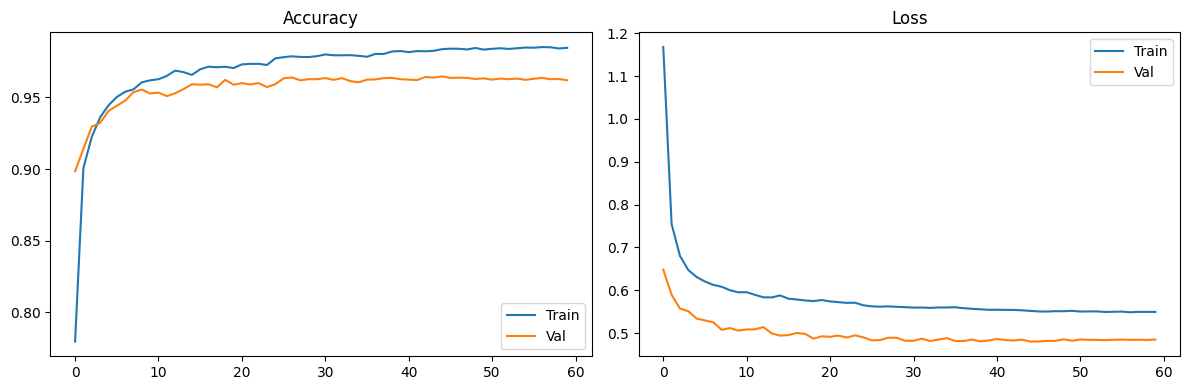

24/24 [==============================] - 1s 8ms/step

BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - v30_tcn (Threshold 0.25)
              precision    recall  f1-score   support

        Walk     0.9835    0.9370    0.9597      1906
         Run     0.9807    0.9853    0.9830      1085
        Idle     0.9284    0.9733    0.9503      1798
       Trans     0.9185    0.9347    0.9266       567
        Fall     0.9864    0.9707    0.9785       750

    accuracy                         0.9602      6106
   macro avg     0.9595    0.9602    0.9596      6106
weighted avg     0.9611    0.9602    0.9603      6106




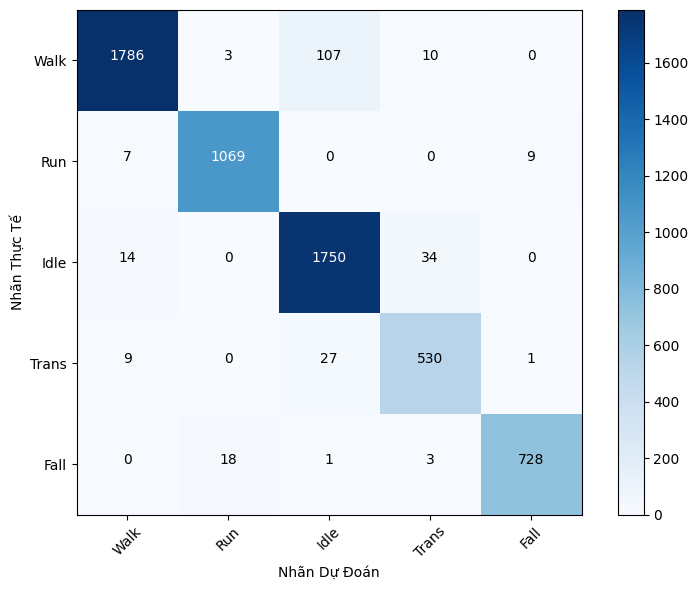


KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):
  - Số ca ngã thực tế: 750
  - Số ca ngã phát hiện đúng: 728
  - TỶ LỆ RECALL TÉ NGÃ: 97.07%

[*] Đã lưu báo cáo tại /media/data3/users/hungvm/dataset/sisfall/workspace/output_v30_tcn/report_v30_tcn.txt


In [4]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

class FallDetectionTrainerResize(DataPreprocessor, OutputReporter):
    def __init__(self):
        data_dir  = f'{WORKSPACE}/SisFall_dataset_Windowed_v30'
        cache_dir = f'{WORKSPACE}/cache_v30'
        out_dir   = f'{WORKSPACE}/output_v30_tcn'
        class_names = ['Walk', 'Run', 'Idle', 'Trans', 'Fall']
        DataPreprocessor.__init__(self, data_dir, cache_dir, class_names)
        OutputReporter.__init__(self, out_dir, class_names)
        self.version = "v30_tcn"

trainer = FallDetectionTrainerResize()
checkpoint_path = Path(trainer.out_dir) / f'best_model_{trainer.version}.keras'

# 1. Nạp + tiền xử lý
X_train, y_train, X_val, y_val, X_test, y_test = trainer.load_or_create_dataset()

# === Augment Trans: nhan bien do x0.9 va x1.1 (CHI train, TRUOC preprocessing) ===
ti = trainer.class_names.index('Trans')
tmask = np.where(y_train == ti)[0]
if len(tmask) > 0:
    Xt = X_train[tmask]
    X_train = np.concatenate([X_train, (Xt*0.9).astype(np.float32), (Xt*1.1).astype(np.float32)], axis=0)
    y_train = np.concatenate([y_train, np.full(len(Xt), ti, y_train.dtype), np.full(len(Xt), ti, y_train.dtype)])
    _p = np.random.RandomState(42).permutation(len(X_train)); X_train, y_train = X_train[_p], y_train[_p]
    print('Da augment Trans x0.9/x1.1 ->', len(tmask), 'x3')

X_train, X_val, X_test = trainer.apply_preprocessing(X_train, X_val, X_test)
print("Phân bố nhãn train:", {trainer.class_names[k]: int((y_train==k).sum()) for k in range(5)})

# 2. Class weights (đẩy Fall x3)
weight_modifiers = {'Fall': 3.0, 'Trans': 0.55, 'Idle': 1.0}
class_weights = trainer.get_balanced_class_weights(y_train, weight_modifiers)

# 3. One-hot
y_train_oh = to_categorical(y_train, num_classes=5)
y_val_oh = to_categorical(y_val, num_classes=5)

# 4. Build model RESIZE
model = build_model(input_shape=(200, 6), n_classes=5)
model.summary()

# 5. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1),
]

# 6. Train
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

# 7. Đánh giá
trainer.plot_training_history(history, version=trainer.version)
trainer.evaluate_and_report(model, X_test, y_test, version=trainer.version, fall_threshold=0.25)

# 7. Export INT8 TFLite → `model_data_v1_resize.cc/.h`

In [ ]:
# === Export INT8 TFLite + sinh model_data .cc/.h (NHUNG SAN ops cho TFLM wrapper) ===
import numpy as np
ver = trainer.version
out_dir = Path(trainer.out_dir)

np.random.seed(42)
rep_idx = np.random.choice(len(X_train), size=min(300, len(X_train)), replace=False)
def representative_data_gen():
    for i in rep_idx:
        yield [X_train[i:i+1].astype(np.float32)]

static_in = tf.keras.Input(batch_shape=(1, 200, 6), dtype='float32')
static_model = tf.keras.models.clone_model(model, input_tensors=static_in)
static_model.set_weights(model.get_weights())

converter = tf.lite.TFLiteConverter.from_keras_model(static_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

tflite_path = out_dir / f'model_{ver}_int8.tflite'
tflite_path.write_bytes(tflite_model)
print(f"[*] Saved {tflite_path}  ({len(tflite_model)} bytes)")

it = tf.lite.Interpreter(model_content=tflite_model); it.allocate_tensors()
inp = it.get_input_details()[0]; outp = it.get_output_details()[0]
all_ops = sorted({d['op_name'] for d in it._get_ops_details()})
NON_REG = {'DELEGATE', 'CALL_ONCE', 'CUSTOM'}
reg_ops = [o for o in all_ops if o not in NON_REG]
in_scale, in_zp = inp['quantization']; out_scale, out_zp = outp['quantization']
in_len = int(np.prod(inp['shape'])); out_len = int(np.prod(outp['shape']))
print("[*] Input :", inp['shape'], inp['dtype'])
print("[*] Output:", outp['shape'], outp['dtype'])
print("[*] Ops can dang ky:", reg_ops)

OP2ADD = {
    'CONV_2D':'AddConv2D','DEPTHWISE_CONV_2D':'AddDepthwiseConv2D','MAX_POOL_2D':'AddMaxPool2D',
    'AVERAGE_POOL_2D':'AddAveragePool2D','MEAN':'AddMean','FULLY_CONNECTED':'AddFullyConnected',
    'SOFTMAX':'AddSoftmax','LOGISTIC':'AddLogistic','RELU6':'AddRelu6','RESHAPE':'AddReshape',
    'ADD':'AddAdd','MUL':'AddMul','CONCATENATION':'AddConcatenation','PAD':'AddPad',
    'QUANTIZE':'AddQuantize','DEQUANTIZE':'AddDequantize','STRIDED_SLICE':'AddStridedSlice',
}
res_lines = []
for o in reg_ops:
    m2 = OP2ADD.get(o)
    res_lines.append(f"//   resolver.{m2}();" if m2 else f"//   /* op '{o}': tu tra cuu Add method */")

meta = (
    "// ============================================================\n"
    f"// AUTO-GENERATED model data  --  {ver}\n"
    f"// TFLite INT8 size : {len(tflite_model)} bytes\n"
    "// ------------------------------------------------------------\n"
    f"// Input  : shape={list(inp['shape'])} dtype={inp['dtype'].__name__} quant(scale={in_scale:.8g}, zero_point={in_zp})\n"
    f"// Output : shape={list(outp['shape'])} dtype={outp['dtype'].__name__} quant(scale={out_scale:.8g}, zero_point={out_zp})\n"
    "// INT8<->real:  q = round(real/scale)+zero_point ; real = (q-zero_point)*scale\n"
    "// ------------------------------------------------------------\n"
    f"// OPS cua mang ({len(reg_ops)}) -- dang ky DUNG nhung op nay:\n"
    + "".join(f"//   - {o}\n" for o in reg_ops)
    + (f"// (Bo qua pseudo-op: {', '.join(o for o in all_ops if o in NON_REG)})\n" if any(o in NON_REG for o in all_ops) else "")
    + "//\n"
    f"// GOI Y MicroMutableOpResolver (so op = {len(reg_ops)}):\n"
    f"//   static tflite::MicroMutableOpResolver<{len(reg_ops)}> resolver;\n"
    + "".join(l + "\n" for l in res_lines)
    + "// ============================================================\n"
)

body, line = '', '  '
for i, b in enumerate(tflite_model):
    line += f'0x{b:02x}, '
    if (i+1) % 12 == 0:
        body += line.rstrip() + '\n'; line = '  '
if line.strip():
    body += line.rstrip()
body = body.rstrip(', \n')

cc = (meta + '#include "model_data.h"\n\n'
      f'const unsigned char g_model_data[] alignas(16) = {{\n{body}\n}};\n\n'
      f'const unsigned int g_model_data_len = {len(tflite_model)};\n')
(out_dir / f'model_data_{ver}.cc').write_text(cc, encoding='utf-8')

h = (meta + "#ifndef MODEL_DATA_H_\n#define MODEL_DATA_H_\n\n"
     f"#define MODEL_INPUT_LEN   {in_len}\n#define MODEL_OUTPUT_LEN  {out_len}\n#define MODEL_NUM_OPS     {len(reg_ops)}\n\n"
     '#ifdef __cplusplus\nextern "C" {\n#endif\n\n'
     "extern const unsigned char g_model_data[];\nextern const unsigned int g_model_data_len;\n\n"
     "#ifdef __cplusplus\n}\n#endif\n\n#endif  // MODEL_DATA_H_\n")
(out_dir / f'model_data_{ver}.h').write_text(h, encoding='utf-8')
print(f"[*] Da sinh model_data_{ver}.cc / .h")
